# Creación de 1 señal 

En esta sección se importan las librerías necesarias para generar señales, calcular su análisis en frecuencia y visualizar resultados en gráficas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft


Aquí se define la primera señal senoidal `x1`, estableciendo frecuencia, periodo de muestreo, vector de tiempo y amplitud.

In [2]:

f = 20  # hz 
T = 1/f # 50ms; 0.05 s# Creación de 1 señal 
phi = 0

w = 2*np.pi*f

fs = 20*f   # 100 sps
ts = 1/fs  # 10 ms; 0.01 s
n = np.arange(0, 4*T*fs)
t = n*ts

A1 = 10

x1 = A1*np.sin(w*t + phi)



## Gráficas asociadas a la señal, Opción1 

En esta opción se visualiza la señal en el tiempo, su espectro de magnitud y una representación tiempo-frecuencia usando `specgram`.

/tmp/ipykernel_21617/953629616.py:21: UserWarning: Only one segment is calculated since parameter NFFT (=4096) >= signal length (=80).
  Pxx, freqs, bins, im = plt.specgram(x1, NFFT=4096, Fs=fs, noverlap=128, scale='dB')# Creación de 1 señal T=64, Fs=fs, noverlap=32, scale='dB')


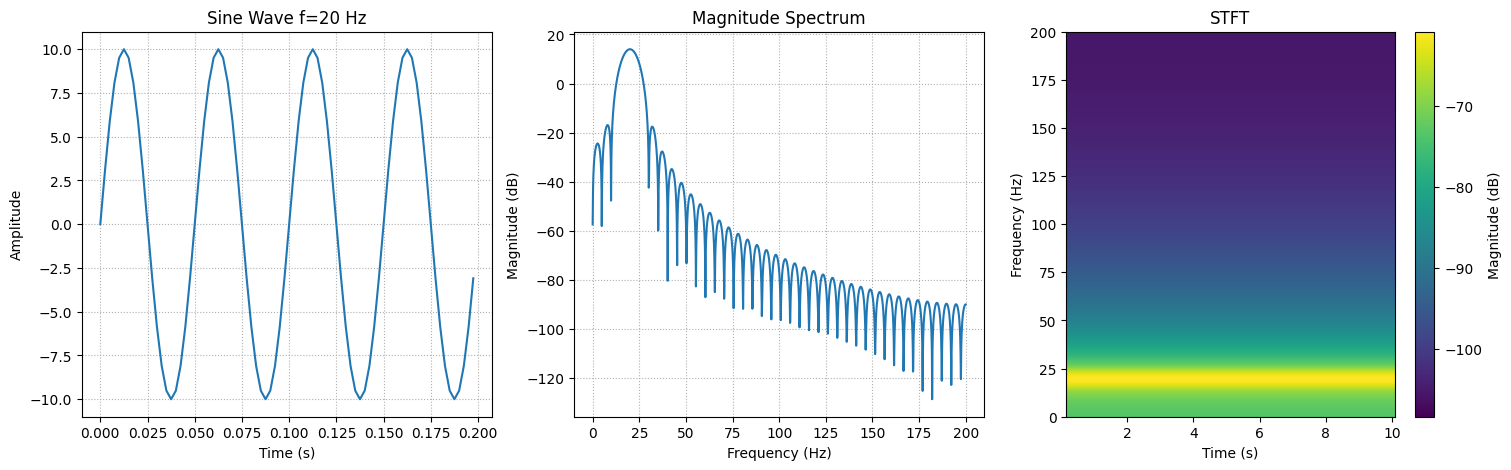

In [3]:
plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
plt.title('Sine Wave f={} Hz'.format(f))
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.plot(t,x1)
plt.grid(ls=":")

plt.subplot(1,3,2)
plt.title('Magnitude Spectrum')
plt.magnitude_spectrum(x1, Fs=fs, pad_to=4096,  scale='dB')
plt.grid(ls=":")
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
#plt.xticks(np.arange(0, fs/2 + 1, 10))

plt.subplot(1,3,3)
plt.title("STFT")
#plt.specgram(x1, NFFT=4096, Fs=fs, noverlap=128, scale='dB')
Pxx, freqs, bins, im = plt.specgram(x1, NFFT=4096, Fs=fs, noverlap=128, scale='dB')# Creación de 1 señal T=64, Fs=fs, noverlap=32, scale='dB')
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')    
plt.colorbar(im, label='Magnitude (dB)')

plt.show()

## Gráficas asociadas a la señal, Opción2

En esta segunda opción se calcula explícitamente la FFT y la STFT para obtener un análisis más controlado de la señal `x1`.

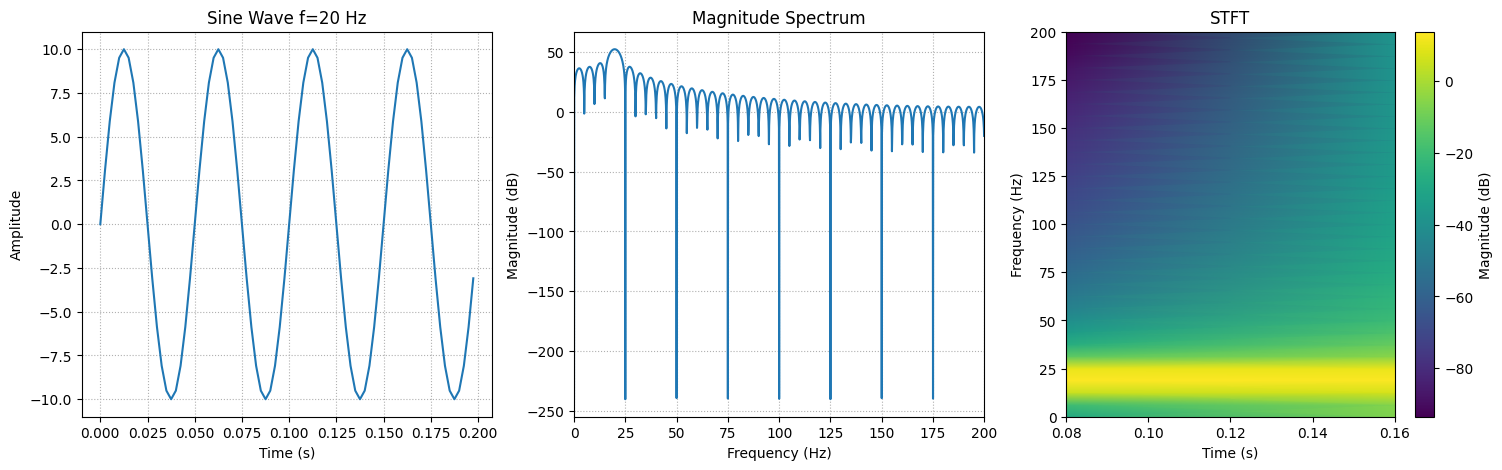

In [4]:
# FFT

N = 4096
X = np.fft.fft(x1, n=N)
f_fft = np.fft.fftfreq(N, d=1/fs)


# STFT
f_stft, t_stft, Zxx = stft(
    x1,
    fs=fs,
    window='hann',
    nperseg=64,
    noverlap=32,
    nfft=64,
    boundary=None
)

# Magnitud en dB
Zxx_dB = 20 * np.log10(np.abs(Zxx) + 1e-12)

plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
plt.title('Sine Wave f={} Hz'.format(f))
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.plot(t, x1)
plt.grid(ls=":")

plt.subplot(1,3,2)
plt.title('Magnitude Spectrum')
plt.plot(f_fft[:N//2], 20*np.log10(np.abs(X[:N//2]) + 1e-12))
plt.xlim(0, fs/2)
plt.xticks(np.arange(0, fs/2 + 1, 25))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.grid(ls=":")

plt.subplot(1,3,3)
plt.title("STFT")
plt.pcolormesh(t_stft, f_stft, Zxx_dB, shading='gouraud')
plt.ylabel("Frequency (Hz)")
plt.xlabel("Time (s)")
plt.colorbar(label="Magnitude (dB)")
plt.ylim(0, fs/2)

plt.show()

# Creación de 2 señales

Aquí se construye una señal compuesta de 2 componentes senoidales (`x1` y `x2`) con diferentes frecuencias y amplitudes.

In [5]:
# Creación de 2 señales (siguiendo el mismo patrón)

f1 = f          # Hz (ya definida: 20 Hz)
A2 = 6          # amplitud de la segunda señal
f2 = 60         # Hz
phi2 = 0        # fase inicial

w2 = 2 * np.pi * f2

x2 = A2 * np.sin(w2 * t + phi2)
x12 = x1 + x2   # señal compuesta de 2 señales

En este bloque se analizan las 2 señales combinadas mediante gráfica temporal, FFT y STFT para observar sus componentes de frecuencia.

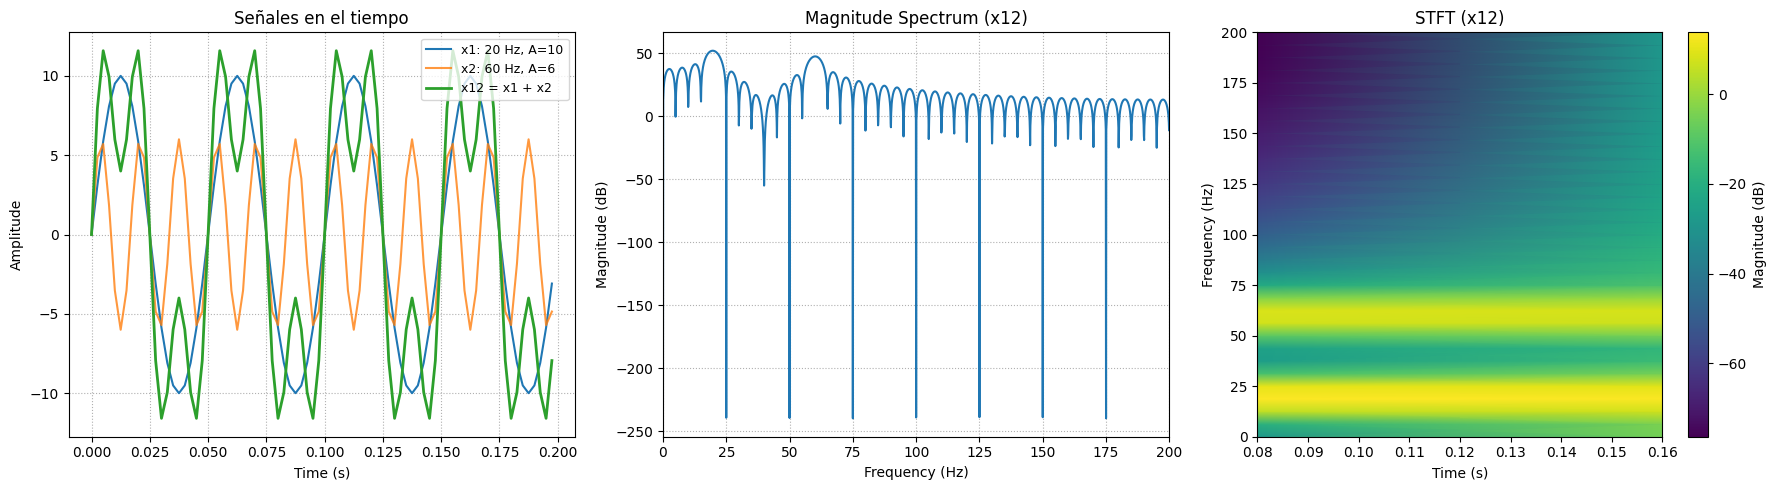

In [6]:
# Gráficas asociadas a 2 señales (x1, x2 y señal compuesta x12)

# FFT de la señal compuesta
N = 4096
X12 = np.fft.fft(x12, n=N)
f_fft12 = np.fft.fftfreq(N, d=1/fs)

# STFT de la señal compuesta
f_stft12, t_stft12, Zxx12 = stft(
    x12,
    fs=fs,
    window='hann',
    nperseg=64,
    noverlap=32,
    nfft=64,
    boundary=None
)

# Magnitud en dB
Zxx12_dB = 20 * np.log10(np.abs(Zxx12) + 1e-12)

plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
plt.title('Señales en el tiempo')
plt.plot(t, x1, label='x1: 20 Hz, A=10')
plt.plot(t, x2, label='x2: 60 Hz, A=6', alpha=0.8)
plt.plot(t, x12, label='x12 = x1 + x2', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(ls=':')
plt.legend(loc='upper right', fontsize=9)

plt.subplot(1,3,2)
plt.title('Magnitude Spectrum (x12)')
plt.plot(f_fft12[:N//2], 20*np.log10(np.abs(X12[:N//2]) + 1e-12))
plt.xlim(0, fs/2)
plt.xticks(np.arange(0, fs/2 + 1, 25))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(ls=':')

plt.subplot(1,3,3)
plt.title('STFT (x12)')
plt.pcolormesh(t_stft12, f_stft12, Zxx12_dB, shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(label='Magnitude (dB)')
plt.ylim(0, fs/2)

plt.tight_layout()
plt.show()

# Creación de 3 señales

Aquí se añade una tercera componente senoidal `x3` y se forma la señal compuesta `x123`.

In [7]:
# Creación de 3 señales (siguiendo el mismo patrón)

A3 = 4          # amplitud de la tercera señal
f3 = 90         # Hz
phi3 = 0        # fase inicial

w3 = 2 * np.pi * f3
x3 = A3 * np.sin(w3 * t + phi3)
x123 = x1 + x2 + x3   # señal compuesta de 3 señales


En esta parte se visualiza la señal de 3 componentes con su representación en tiempo, su espectro (FFT) y su análisis tiempo-frecuencia (STFT).

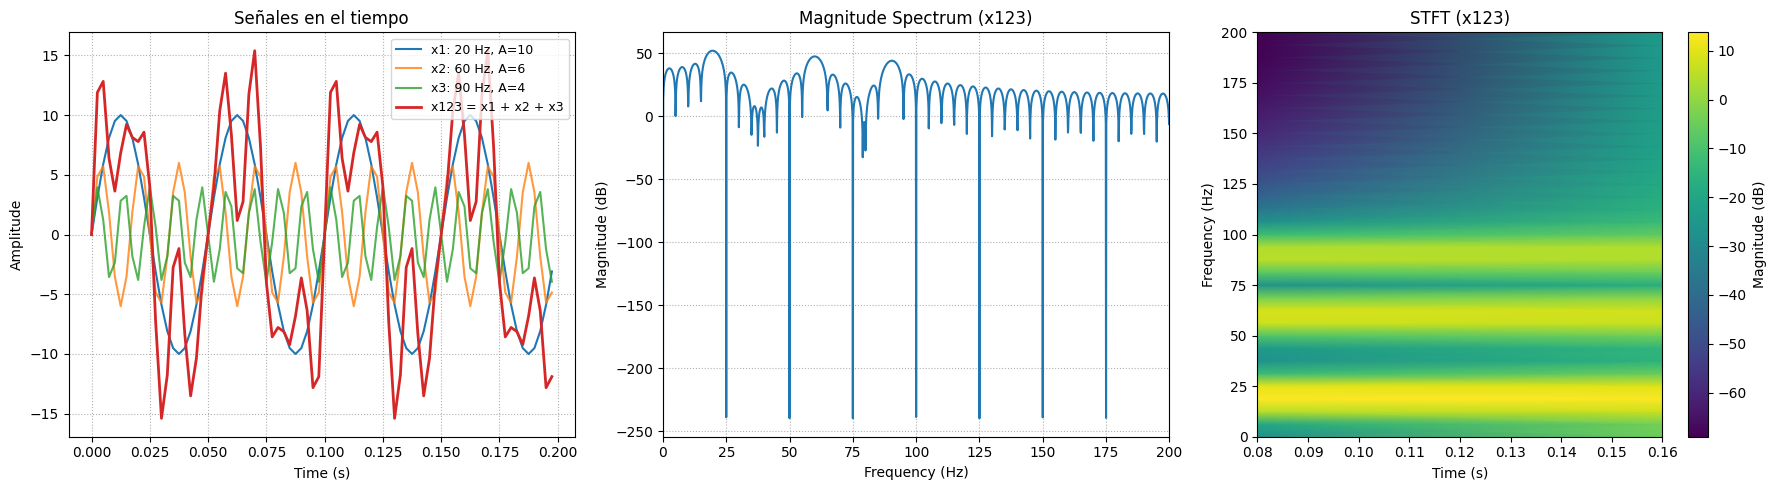

In [8]:

# FFT de la señal compuesta
N = 4096
X123 = np.fft.fft(x123, n=N)
f_fft123 = np.fft.fftfreq(N, d=1/fs)

# STFT de la señal compuesta
f_stft123, t_stft123, Zxx123 = stft(
    x123,
    fs=fs,
    window='hann',
    nperseg=64,
    noverlap=32,
    nfft=64,
    boundary=None
)

# Magnitud en dB
Zxx123_dB = 20 * np.log10(np.abs(Zxx123) + 1e-12)

plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
plt.title('Señales en el tiempo')
plt.plot(t, x1, label='x1: 20 Hz, A=10')
plt.plot(t, x2, label='x2: 60 Hz, A=6', alpha=0.8)
plt.plot(t, x3, label='x3: 90 Hz, A=4', alpha=0.8)
plt.plot(t, x123, label='x123 = x1 + x2 + x3', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(ls=':')
plt.legend(loc='upper right', fontsize=9)

plt.subplot(1,3,2)
plt.title('Magnitude Spectrum (x123)')
plt.plot(f_fft123[:N//2], 20*np.log10(np.abs(X123[:N//2]) + 1e-12))
plt.xlim(0, fs/2)
plt.xticks(np.arange(0, fs/2 + 1, 25))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(ls=':')

plt.subplot(1,3,3)
plt.title('STFT (x123)')
plt.pcolormesh(t_stft123, f_stft123, Zxx123_dB, shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(label='Magnitude (dB)')
plt.ylim(0, fs/2)

plt.tight_layout()
plt.show()

# Creación de 4 señales + ruido (siguiendo el mismo patrón)


En esta sección se incorpora una cuarta señal `x4` y ruido gaussiano para simular una medición más realista.

In [9]:

A4 = 3          # amplitud de la cuarta señal
f4 = 120        # Hz
phi4 = 0        # fase inicial

w4 = 2 * np.pi * f4
x4 = A4 * np.sin(w4 * t + phi4)

# Ruido gaussiano
np.random.seed(42)
noise_std = 1.2
ruido = noise_std * np.random.randn(len(t))

# Señal compuesta de 4 señales + ruido
x4n = x1 + x2 + x3 + x4 + ruido


Aquí se analiza la señal final `x4n` (4 señales + ruido) usando dominio del tiempo, FFT y STFT para identificar cómo afecta el ruido al contenido espectral.

<Figure size 1800x500 with 0 Axes>

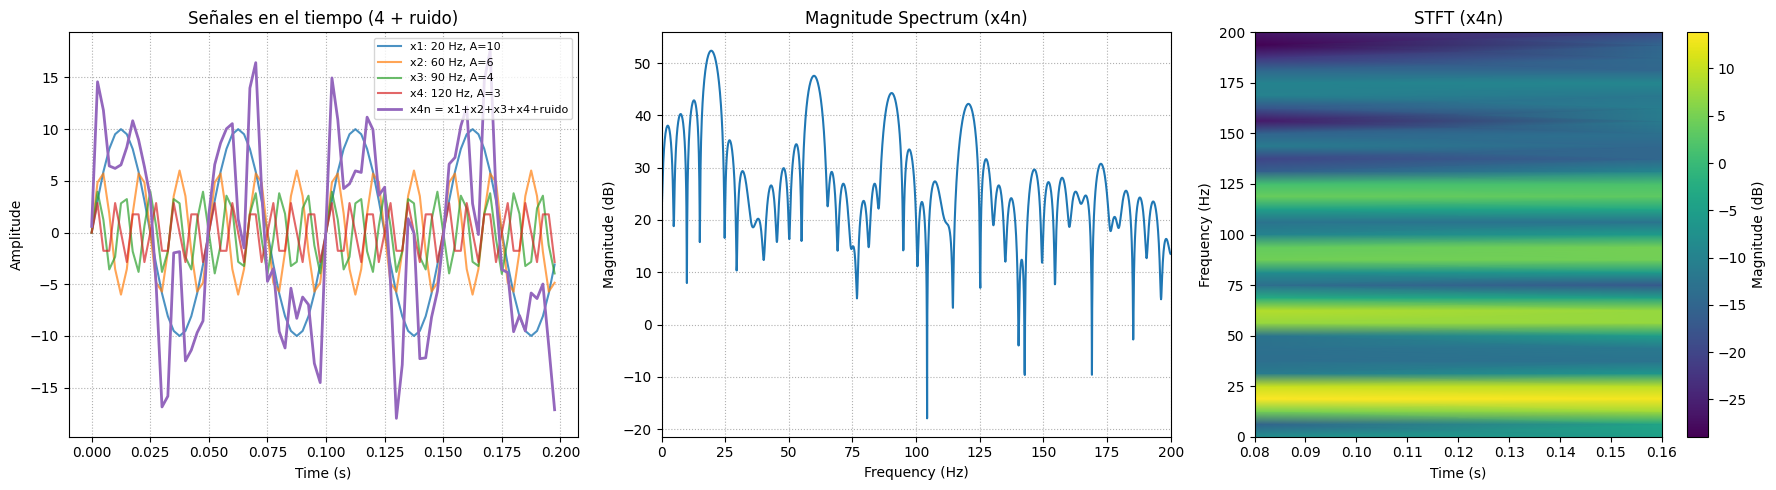

In [12]:

# FFT de la señal compuesta
N = 4096
X4n = np.fft.fft(x4n, n=N)
f_fft4n = np.fft.fftfreq(N, d=1/fs)

# STFT de la señal compuesta
f_stft4n, t_stft4n, Zxx4n = stft(
    x4n,
    fs=fs,
    window='hann',
    nperseg=64,
    noverlap=32,
    nfft=64,
    boundary=None
)

# Magnitud en dB
Zxx4n_dB = 20 * np.log10(np.abs(Zxx4n) + 1e-12)

plt.figure(figsize=(18, 5))
# FFT de la señal compuesta
N = 4096
X4n = np.fft.fft(x4n, n=N)
f_fft4n = np.fft.fftfreq(N, d=1/fs)

# STFT de la señal compuesta
f_stft4n, t_stft4n, Zxx4n = stft(
    x4n,
    fs=fs,
    window='hann',
    nperseg=64,
    noverlap=32,
    nfft=64,
    boundary=None
)

# Magnitud en dB
Zxx4n_dB = 20 * np.log10(np.abs(Zxx4n) + 1e-12)

plt.figure(figsize=(18, 5))

plt.subplot(1,3,1)
plt.title('Señales en el tiempo (4 + ruido)')
plt.plot(t, x1, label='x1: 20 Hz, A=10', alpha=0.8)
plt.plot(t, x2, label='x2: 60 Hz, A=6', alpha=0.7)
plt.plot(t, x3, label='x3: 90 Hz, A=4', alpha=0.7)
plt.plot(t, x4, label='x4: 120 Hz, A=3', alpha=0.7)
plt.plot(t, x4n, label='x4n = x1+x2+x3+x4+ruido', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(ls=':')
plt.legend(loc='upper right', fontsize=8)

plt.subplot(1,3,2)
plt.title('Magnitude Spectrum (x4n)')
plt.plot(f_fft4n[:N//2], 20*np.log10(np.abs(X4n[:N//2]) + 1e-12))
plt.xlim(0, fs/2)
plt.xticks(np.arange(0, fs/2 + 1, 25))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(ls=':')

plt.subplot(1,3,3)
plt.title('STFT (x4n)')
plt.pcolormesh(t_stft4n, f_stft4n, Zxx4n_dB, shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(label='Magnitude (dB)')
plt.ylim(0, fs/2)

plt.tight_layout()
plt.show()

# plt.figure(figsize=(18, 5))

# plt.subplot(1,3,1)
# plt.title('Señales en el tiempo (4 + ruido)')
# plt.plot(t, x1, label='x1: 20 Hz, A=10', alpha=0.8)
# plt.plot(t, x2, label='x2: 60 Hz, A=6', alpha=0.7)
# plt.plot(t, x3, label='x3: 90 Hz, A=4', alpha=0.7)
# plt.plot(t, x4, label='x4: 120 Hz, A=3', alpha=0.7)
# plt.plot(t, x4n, label='x4n = x1+x2+x3+x4+ruido', linewidth=2)
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')
# plt.grid(ls=':')
# plt.legend(loc='upper right', fontsize=8)

# plt.subplot(1,3,2)
# plt.title('Magnitude Spectrum (x4n)')
# plt.plot(f_fft4n[:N//2], 20*np.log10(np.abs(X4n[:N//2]) + 1e-12))
# plt.xlim(0, fs/2)
# plt.xticks(np.arange(0, fs/2 + 1, 25))
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Magnitude (dB)')
# plt.grid(ls=':')

# plt.subplot(1,3,3)
# plt.title('STFT (x4n)')
# plt.pcolormesh(t_stft4n, f_stft4n, Zxx4n_dB, shading='gouraud')
# plt.ylabel('Frequency (Hz)')
# plt.xlabel('Time (s)')
# plt.colorbar(label='Magnitude (dB)')
# plt.ylim(0, fs/2)

# plt.tight_layout()
# plt.show()